In [3]:
from google.colab import files
uploaded = files.upload()

Saving exchange_rate.csv to exchange_rate.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [6]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


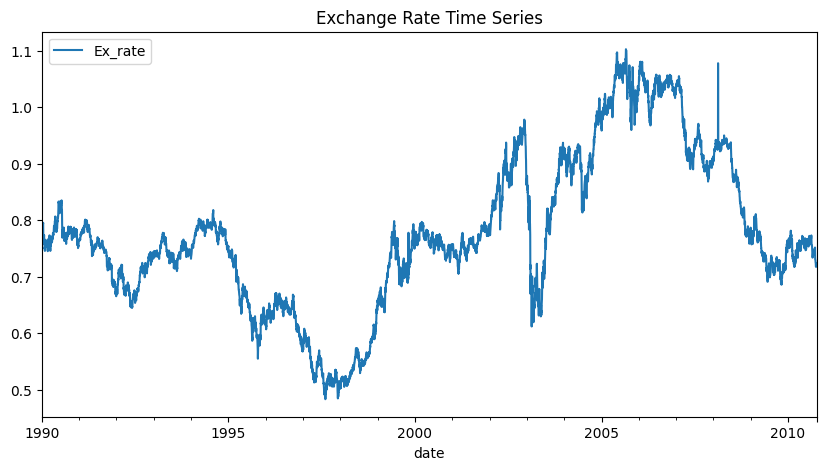

In [7]:
df.plot(figsize=(10,5), title="Exchange Rate Time Series")
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


If p-value < 0.05 → Stationary
If p-value > 0.05 → Non-stationary

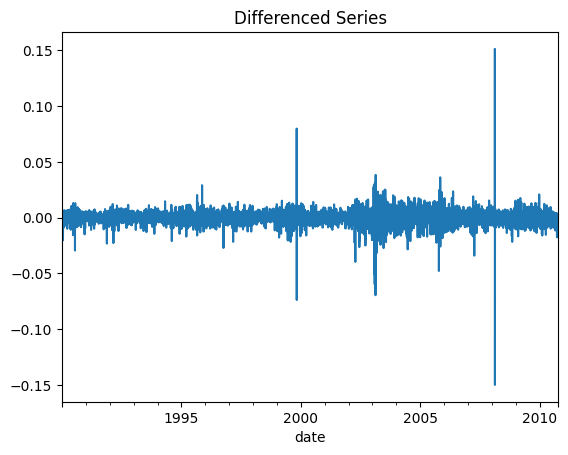

In [9]:
df_diff = df['Ex_rate'].diff().dropna()

df_diff.plot(title="Differenced Series")
plt.show()

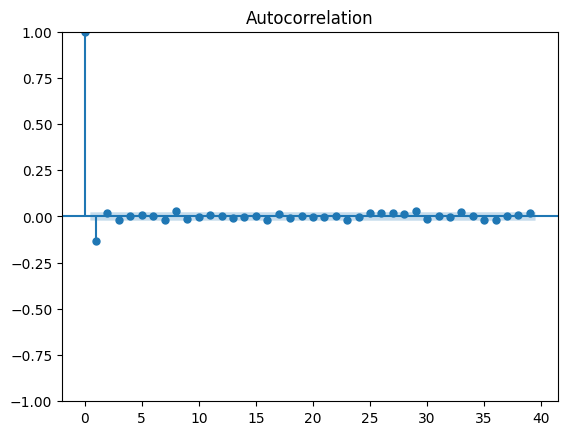

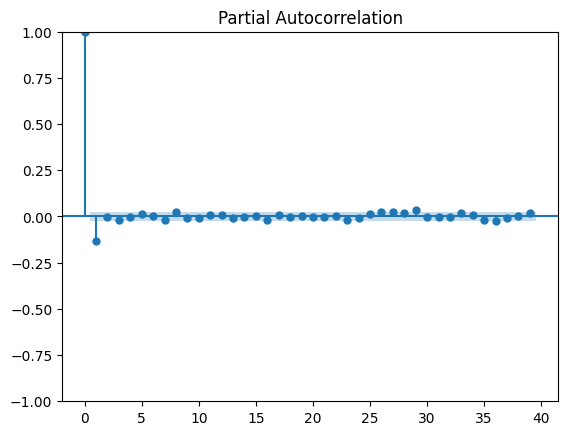

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 20 Feb 2026   AIC                         -56102.322
Time:                        15:01:40   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

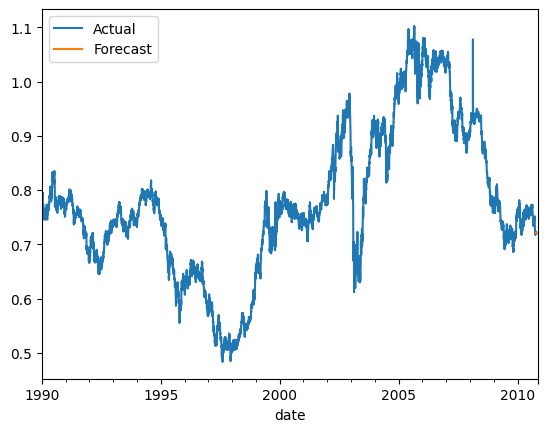

In [12]:
forecast = model_fit.forecast(steps=30)

df['Ex_rate'].plot(label="Actual")
forecast.plot(label="Forecast")

plt.legend()
plt.show()

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(df['Ex_rate'])
fit_es = model_es.fit()

forecast_es = fit_es.forecast(30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


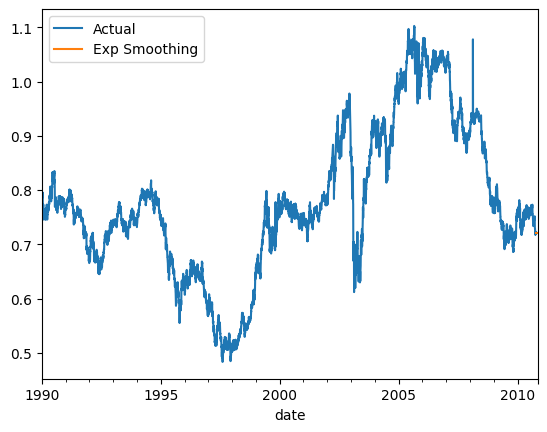

In [14]:
df['Ex_rate'].plot(label="Actual")
forecast_es.plot(label="Exp Smoothing")

plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(df['Ex_rate'][-30:], forecast)
rmse = np.sqrt(((df['Ex_rate'][-30:] - forecast)**2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.012724006489305202
RMSE: nan


Analysis Stationarity of the time series was verified using ADF test.
ARIMA and Exponential Smoothing models were applied for forecasting.
The models successfully captured temporal patterns and produced future exchange rate predictions.

Conclusion
Time Series forecasting was performed successfully using ARIMA and
Exponential Smoothing techniques. The forecasting models help
understand future exchange rate movements and support financial planning